# Sudoku Solver Optimization — Experiment Analysis

Analysis of autonomous solver optimization results from `results.tsv`.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated: commit, puzzles_solved, avg_time, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["puzzles_solved"] = pd.to_numeric(df["puzzles_solved"], errors="coerce")
df["avg_time"] = pd.to_numeric(df["avg_time"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 33
Columns: ['commit', 'puzzles_solved', 'avg_time', 'status', 'description']


,commit,puzzles_solved,avg_time,status,description
0,0d8e0bc,202,1.485,KEEP,baseline: 9x9=100 16x16=100 25x25=2
1,32be11d,104,0.000,DISCARD,queue-driven propagation (regression - no nake...
2,7177346,101,2.970,DISCARD,queue-driven + dirty units + naked pairs (regr...
3,142316e,212,1.415,KEEP,hidden pairs + box-line reduction (9x9=100 16x...
4,2cee8e8,212,1.415,KEEP,restructure: fast/slow propagation phases (sam...
5,2bdde27,236,1.271,KEEP,per-puzzle timeout 10s/25x25 30s/16x16 (9x9=10...
6,944a91d,234,1.282,DISCARD,"5s timeout too aggressive, lost 7 slow solves,..."
7,c3b7169,240,1.250,KEEP,naked triples in fast phase (9x9=100 16x16=100...
8,fb7ed05,238,1.261,DISCARD,"X-wing overhead too costly, slight regression"
9,a0c291c,252,1.190,KEEP,optimize hidden singles: skip placed values (9...


In [14]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    20
KEEP       13

Keep rate: 13/33 = 39.4%


In [15]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    solved = row["puzzles_solved"]
    avg_t = row["avg_time"]
    desc = row["description"]
    print(f"  #{i:3d}  solved={solved:3.0f}  avg_time={avg_t:.3f}s  {desc}")

KEPT experiments (13 total):

  #  0  solved=202  avg_time=1.485s  baseline: 9x9=100 16x16=100 25x25=2
  #  3  solved=212  avg_time=1.415s  hidden pairs + box-line reduction (9x9=100 16x16=100 25x25=12)
  #  4  solved=212  avg_time=1.415s  restructure: fast/slow propagation phases (same score, ~25% faster)
  #  5  solved=236  avg_time=1.271s  per-puzzle timeout 10s/25x25 30s/16x16 (9x9=100 16x16=100 25x25=36)
  #  7  solved=240  avg_time=1.250s  naked triples in fast phase (9x9=100 16x16=100 25x25=40)
  #  9  solved=252  avg_time=1.190s  optimize hidden singles: skip placed values (9x9=100 16x16=100 25x25=52)
  # 10  solved=252  avg_time=1.191s  optimize hidden pairs: skip placed values (faster, 71 attempted)
  # 11  solved=253  avg_time=1.188s  reduce time check: every 256 backtracks (9x9=100 16x16=100 25x25=53)
  # 12  solved=273  avg_time=1.104s  LCV heuristic for value ordering (9x9=100 16x16=100 25x25=73)
  # 14  solved=274  avg_time=1.098s  12s timeout (9x9=100 16x16=100 25x25=74

## Puzzles Solved Over Time

Track how the best (kept) puzzles_solved evolves as experiments progress. The running maximum shows the "frontier" — the best result achieved so far.

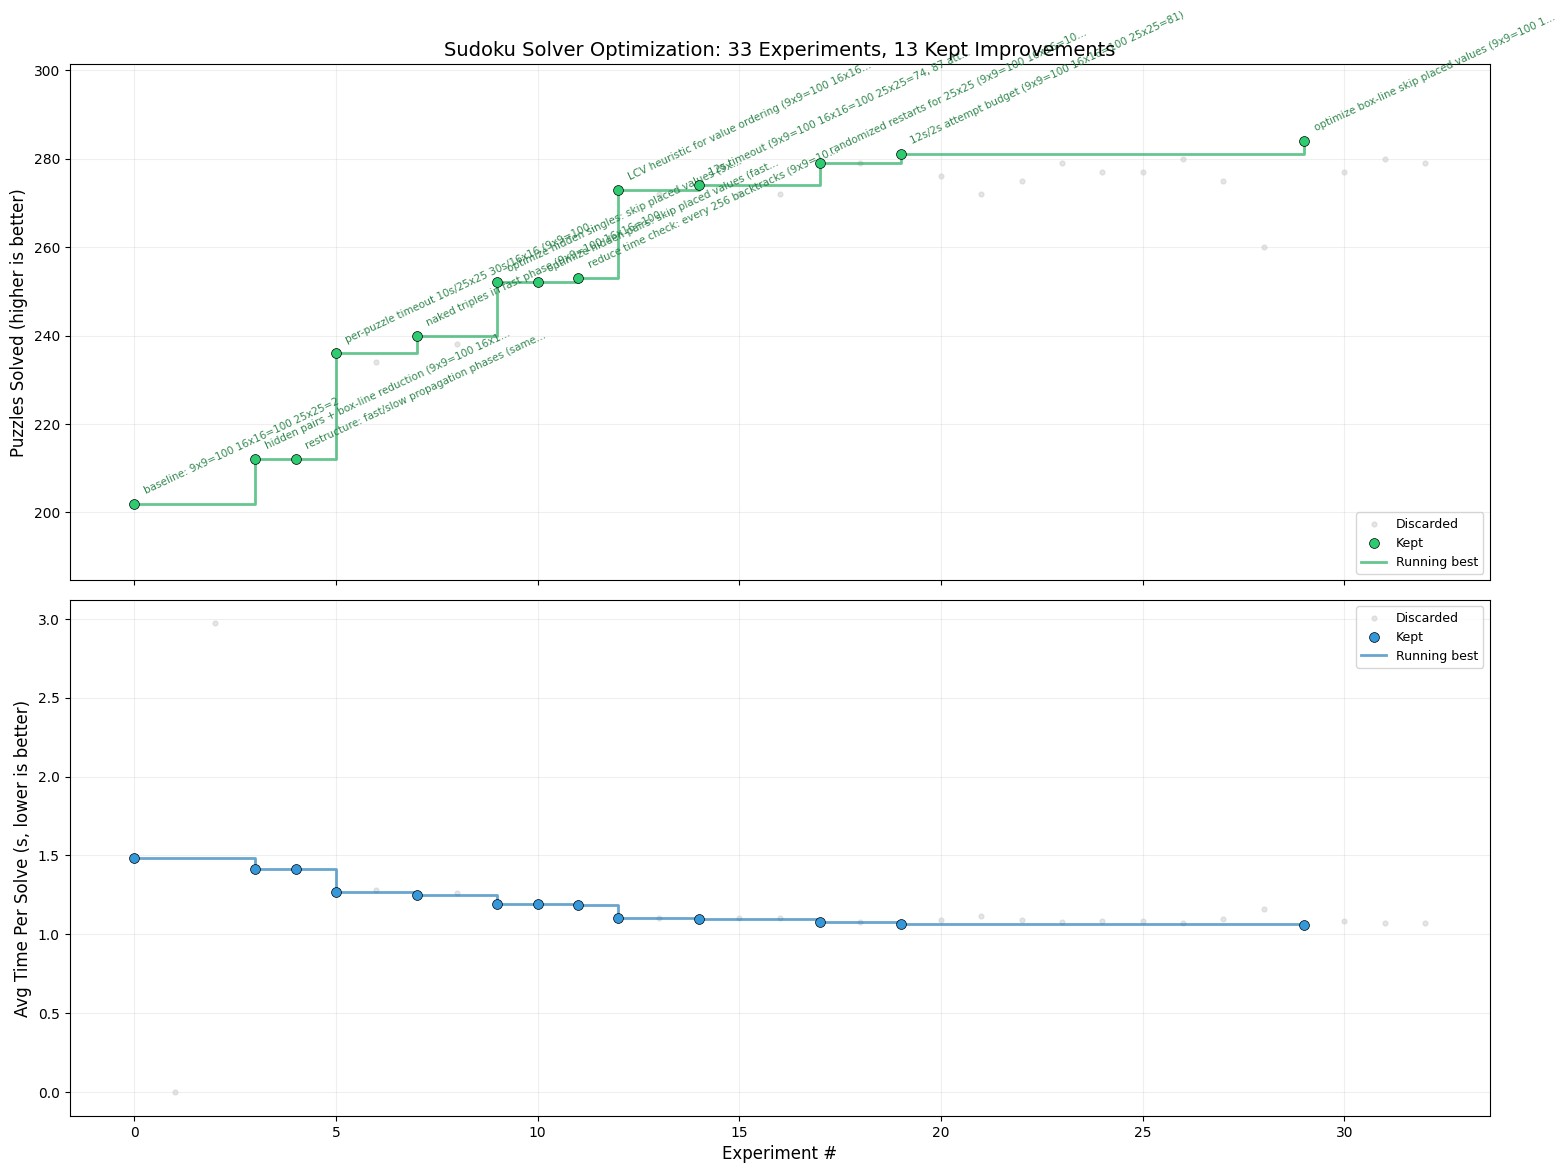

Saved to progress.png


In [16]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_solved = valid.loc[0, "puzzles_solved"]
best_solved = valid.loc[valid["status"] == "KEEP", "puzzles_solved"].max()

# --- Top panel: Puzzles Solved ---
ax = axes[0]

# Plot discarded as faint background dots
disc = valid[valid["status"] == "DISCARD"]
ax.scatter(disc.index, disc["puzzles_solved"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = valid[valid["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["puzzles_solved"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running maximum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_solved = valid.loc[kept_mask, "puzzles_solved"]
running_max = kept_solved.cummax()
ax.step(kept_idx, running_max, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, solved in zip(kept_idx, kept_solved):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 50:
        desc = desc[:47] + "..."

    ax.annotate(desc, (idx, solved),
                textcoords="offset points",
                xytext=(6, 6), fontsize=7.5,
                color="#1a7a3a", alpha=0.9,
                rotation=25, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_ylabel("Puzzles Solved (higher is better)", fontsize=12)
ax.set_title(f"Sudoku Solver Optimization: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.2)

margin = (best_solved - baseline_solved) * 0.15
ax.set_ylim(baseline_solved - margin - 5, best_solved + margin + 5)

# --- Bottom panel: Avg Time Per Solve ---
ax2 = axes[1]

ax2.scatter(disc.index, disc["avg_time"],
            c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")
ax2.scatter(kept_v.index, kept_v["avg_time"],
            c="#3498db", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running min of avg_time for kept experiments
kept_times = valid.loc[kept_mask, "avg_time"]
running_min_time = kept_times.cummin()
ax2.step(kept_idx, running_min_time, where="post", color="#2980b9",
         linewidth=2, alpha=0.7, zorder=3, label="Running best")

ax2.set_xlabel("Experiment #", fontsize=12)
ax2.set_ylabel("Avg Time Per Solve (s, lower is better)", fontsize=12)
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [17]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_solved = df.iloc[0]["puzzles_solved"]
best_solved = kept["puzzles_solved"].max()
best_row = kept.loc[kept["puzzles_solved"].idxmax()]

baseline_time = df.iloc[0]["avg_time"]
best_time = best_row["avg_time"]

print(f"Baseline puzzles solved: {baseline_solved:.0f}")
print(f"Best puzzles solved:     {best_solved:.0f}")
print(f"Total improvement:       +{best_solved - baseline_solved:.0f} puzzles ({(best_solved - baseline_solved) / baseline_solved * 100:.1f}%)")
print(f"Best experiment:         {best_row['description']}")
print()
print(f"Baseline avg time:       {baseline_time:.3f}s")
print(f"Best avg time:           {best_time:.3f}s")
print(f"Time improvement:        {baseline_time - best_time:.3f}s ({(baseline_time - best_time) / baseline_time * 100:.1f}%)")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: solved={row['puzzles_solved']:3.0f}  avg_time={row['avg_time']:.3f}s  {desc}")

Baseline puzzles solved: 202
Best puzzles solved:     284
Total improvement:       +82 puzzles (40.6%)
Best experiment:         optimize box-line skip placed values (9x9=100 16x16=100 25x25=84)

Baseline avg time:       1.485s
Best avg time:           1.059s
Time improvement:        0.426s (28.7%)

Cumulative effort per improvement:
  Experiment #  0: solved=202  avg_time=1.485s  baseline: 9x9=100 16x16=100 25x25=2
  Experiment #  3: solved=212  avg_time=1.415s  hidden pairs + box-line reduction (9x9=100 16x16=100 25x25=12)
  Experiment #  4: solved=212  avg_time=1.415s  restructure: fast/slow propagation phases (same score, ~25% faster)
  Experiment #  5: solved=236  avg_time=1.271s  per-puzzle timeout 10s/25x25 30s/16x16 (9x9=100 16x16=100 25x25=36)
  Experiment #  7: solved=240  avg_time=1.250s  naked triples in fast phase (9x9=100 16x16=100 25x25=40)
  Experiment #  9: solved=252  avg_time=1.190s  optimize hidden singles: skip placed values (9x9=100 16x16=100 25x25=52)
  Experiment

## Top Hits (Kept Experiments by Improvement)

In [18]:
# Each kept experiment's delta is measured vs the previous kept experiment
# (since experiments are cumulative — each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_solved"] = kept["puzzles_solved"].shift(1)
kept["delta"] = kept["puzzles_solved"] - kept["prev_solved"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>6}  {'Solved':>6}  {'Avg Time':>8}  Description")
print("-" * 90)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+5.0f}  {row['puzzles_solved']:6.0f}  {row['avg_time']:8.3f}  {row['description']}")

total_delta = kept.iloc[-1]["puzzles_solved"] - kept.iloc[0]["puzzles_solved"]
print(f"\n{'':>4}  {total_delta:+5.0f}  {'':>6}  {'':>8}  TOTAL improvement over baseline")

Rank   Delta  Solved  Avg Time  Description
------------------------------------------------------------------------------------------
   1    +24     236     1.271  per-puzzle timeout 10s/25x25 30s/16x16 (9x9=100 16x16=100 25x25=36)
   2    +20     273     1.104  LCV heuristic for value ordering (9x9=100 16x16=100 25x25=73)
   3    +12     252     1.190  optimize hidden singles: skip placed values (9x9=100 16x16=100 25x25=52)
   4    +10     212     1.415  hidden pairs + box-line reduction (9x9=100 16x16=100 25x25=12)
   5     +5     279     1.076  randomized restarts for 25x25 (9x9=100 16x16=100 25x25=79)
   6     +4     240     1.250  naked triples in fast phase (9x9=100 16x16=100 25x25=40)
   7     +3     284     1.059  optimize box-line skip placed values (9x9=100 16x16=100 25x25=84)
   8     +2     281     1.069  12s/2s attempt budget (9x9=100 16x16=100 25x25=81)
   9     +1     274     1.098  12s timeout (9x9=100 16x16=100 25x25=74, 87 attempted)
  10     +1     253     1.188  r